<span style="font-size:25px; font-weight:bold">Name: Wondwosen Muhea</span><br>
<span style="font-size:20px; font-weight:bold">Course: Advanced Big Data and Data Mining (MSCS-634-M40) </span><br>
<span style="font-size:16px; font-weight:bold">Residence Classification and Clustering Delivery 3</span><br>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, RocCurveDisplay,
                             accuracy_score, f1_score, classification_report, silhouette_score)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster 
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import label_binarize
from sklearn.inspection import permutation_importance 
from sklearn.cluster import AgglomerativeClustering
import multiprocessing


In [2]:
# Set the start method for multiprocessing
# This should be the FIRST thing you do related to multiprocessing in your script.
try:
    multiprocessing.set_start_method('spawn', force=True)
except RuntimeError:
    pass # If already set by another library/framework, ignore.

### 1. Classification algorithms
In housing market analytics, not every task is about predicting exact prices. 
Often, we’re more interested in categorizing homes into meaningful segments 
based on their market value — such as High, Mid, or Low price bands.
This approach helps:
- Buyers quickly identify homes within their budget.
- Sellers and agents understand where a property stands relative to others.
- Analysts and city planners assess trends across different neighborhoods or market conditions.

By converting the continuous SalePrice into discrete classes:
- We simplify the modeling task,
- Enable interpretability, and
- Support strategic decision-making like pricing tiers, marketing plans, or affordability analysis.
In this project, we classified homes based on price bands using two models — Decision Tree and k-Nearest Neighbors (k-NN) — to evaluate how well we can automatically categorize homes and gain insights from the misclassification patterns.

In [3]:

df = pd.read_csv('AmesHousing.csv')
# Drop irrelevant columns immediately
df = df.drop(['Order', 'PID', 'Utilities'], axis=1)

In [4]:
# --- 1. Handling Missing Values (Imputation) ---

# Categorical/Ordinal Columns where NaN means 'None' (absence of feature)
# These columns were identified in Cell 2. Re-list them if needed.
none_impute_cols = [
    'Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
    'MasVnr Type'
]
for col in none_impute_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# Numerical Columns where NaN means '0' (absence of quantity)
# These columns were identified in Cell 2. Re-list them if needed.
zero_impute_cols_num = [
    'Bsmt Full Bath', 'Bsmt Half Bath', 'BsmtFin SF 1', 'BsmtFin SF 2',
    'Bsmt Unf SF', 'Total Bsmt SF', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
    'MasVnr Area'
]
for col in zero_impute_cols_num:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Specific Imputation for 'Lot Frontage': Use median by 'Neighborhood'
if 'Lot Frontage' in df.columns:
    df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))
    # Fill any remaining NaNs (for neighborhoods with all NaNs) with overall median
    df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

# Mode Imputation for specific sparse NaNs (e.g., 'Electrical', 'MS Zoning')
# These columns were identified in Cell 2. Re-list them if needed.
mode_impute_cols = ['Electrical', 'MS Zoning', 'Exterior 1st', 'Exterior 2nd', 'Sale Type', 'Kitchen Qual']
for col in mode_impute_cols:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])


# --- 2. Correcting Inconsistencies / Data Type Issues ---

# Correct 'Garage Yr Blt' where 0 might be illogical if a garage exists
# This handles cases where 'Garage Yr Blt' was 0, but 'Garage Area'/'Garage Cars' were >0
if 'Garage Yr Blt' in df.columns and 'Year Built' in df.columns:
    df.loc[df['Garage Yr Blt'] == 0, 'Garage Yr Blt'] = df['Year Built']

# Ensure 'MSSubClass' is treated as categorical
if 'MSSubClass' in df.columns:
    df['MSSubClass'] = df['MSSubClass'].astype(str)

# --- 3. Outlier Handling (Example: Gr Liv Area) ---
# Remove extreme outliers in 'Gr Liv Area' as they can skew models significantly.
# This keeps data where 'Gr Liv Area' is less than or equal to 4000 sq ft, removing very few extreme outliers.
if 'Gr Liv Area' in df.columns:
    df = df[df['Gr Liv Area'] <= 4000]

# Reset index after dropping rows
df.reset_index(drop=True, inplace=True)

print(f"Shape of df after cleaning: {df.shape}")
print("\nMissing values after cleaning (should be none or minimal):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape of df after cleaning: (2925, 79)

Missing values after cleaning (should be none or minimal):
Mas Vnr Type    1774
Mas Vnr Area      23
dtype: int64


In [5]:

# --- 1. Handling Missing Values (Imputation) ---

# Categorical/Ordinal Columns where NaN means 'None' (absence of feature)
# These columns were identified in Cell 2. Re-list them if needed.
none_impute_cols = [
    'Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
    'MasVnr Type'
]
for col in none_impute_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# Numerical Columns where NaN means '0' (absence of quantity)
# These columns were identified in Cell 2. Re-list them if needed.
zero_impute_cols_num = [
    'Bsmt Full Bath', 'Bsmt Half Bath', 'BsmtFin SF 1', 'BsmtFin SF 2',
    'Bsmt Unf SF', 'Total Bsmt SF', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
    'MasVnr Area'
]
for col in zero_impute_cols_num:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Specific Imputation for 'Lot Frontage': Use median by 'Neighborhood'
if 'Lot Frontage' in df.columns:
    df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))
    # Fill any remaining NaNs (for neighborhoods with all NaNs) with overall median
    df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

# Mode Imputation for specific sparse NaNs (e.g., 'Electrical', 'MS Zoning')
# These columns were identified in Cell 2. Re-list them if needed.
mode_impute_cols = ['Electrical', 'MS Zoning', 'Exterior 1st', 'Exterior 2nd', 'Sale Type', 'Kitchen Qual']
for col in mode_impute_cols:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])


# --- 2. Correcting Inconsistencies / Data Type Issues ---

# Correct 'Garage Yr Blt' where 0 might be illogical if a garage exists
# This handles cases where 'Garage Yr Blt' was 0, but 'Garage Area'/'Garage Cars' were >0
if 'Garage Yr Blt' in df.columns and 'Year Built' in df.columns:
    df.loc[df['Garage Yr Blt'] == 0, 'Garage Yr Blt'] = df['Year Built']

# Ensure 'MSSubClass' is treated as categorical
if 'MSSubClass' in df.columns:
    df['MSSubClass'] = df['MSSubClass'].astype(str)

# --- 3. Outlier Handling (Example: Gr Liv Area) ---
# Remove extreme outliers in 'Gr Liv Area' as they can skew models significantly.
# This keeps data where 'Gr Liv Area' is less than or equal to 4000 sq ft, removing very few extreme outliers.
if 'Gr Liv Area' in df.columns:
    df = df[df['Gr Liv Area'] <= 4000]

# Reset index after dropping rows
df.reset_index(drop=True, inplace=True)

print(f"Shape of df after cleaning: {df.shape}")
print("\nMissing values after cleaning (should be none or minimal):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape of df after cleaning: (2925, 79)

Missing values after cleaning (should be none or minimal):
Mas Vnr Type    1774
Mas Vnr Area      23
dtype: int64


In [6]:
# Assuming 'df' is the cleaned DataFrame from Cell 3.

# --- 1. Area-Related Features ---
# Total living square footage (above and below grade)
df['TotalSF'] = df['1st Flr SF'] + df['2nd Flr SF'] + df['Total Bsmt SF']

# Total number of bathrooms
df['TotalBath'] = df['Full Bath'] + (0.5 * df['Half Bath']) + \
                  df['Bsmt Full Bath'] + (0.5 * df['Bsmt Half Bath'])

# Total porch area
df['TotalPorchSF'] = df['Open Porch SF'] + df['Enclosed Porch'] + \
                     df['3Ssn Porch'] + df['Screen Porch']

# --- 2. Age-Related Features ---
# Age of the house when sold
if 'Year Built' in df.columns and 'Yr Sold' in df.columns:
    df['HouseAge'] = df['Yr Sold'] - df['Year Built']
    # Handle cases where HouseAge might be negative due to errors or future sale year
    df['HouseAge'] = df['HouseAge'].apply(lambda x: x if x >= 0 else 0)

# Age since last remodel (or construction if no remodel)
if 'Year Remod/Add' in df.columns and 'Yr Sold' in df.columns:
    df['RemodelAge'] = df['Yr Sold'] - df['Year Remod/Add']
    df['RemodelAge'] = df['RemodelAge'].apply(lambda x: x if x >= 0 else 0)

# Age of the garage when sold
if 'Garage Yr Blt' in df.columns and 'Yr Sold' in df.columns:
    df['GarageAge'] = df['Yr Sold'] - df['Garage Yr Blt']
    df['GarageAge'] = df['GarageAge'].apply(lambda x: x if x >= 0 else 0)


# --- 3. Interaction Features ---
# Interaction between overall quality and living area
if 'Overall Qual' in df.columns and 'Gr Liv Area' in df.columns:
    df['OverallQual_GrLivArea'] = df['Overall Qual'] * df['Gr Liv Area']

# Interaction between overall quality and total square footage
if 'Overall Qual' in df.columns and 'TotalSF' in df.columns:
    df['OverallQual_TotalSF'] = df['Overall Qual'] * df['TotalSF']

# --- 4. Binary/Presence Features (Flags for amenities) ---
# Indicates if a pool exists (1) or not (0)
if 'Pool QC' in df.columns:
    df['HasPool'] = df['Pool QC'].apply(lambda x: 1 if x != 'None' else 0)

# Indicates if a 2nd floor exists
if '2nd Flr SF' in df.columns:
    df['Has2ndFloor'] = df['2nd Flr SF'].apply(lambda x: 1 if x > 0 else 0)

# Indicates if a garage exists
if 'Garage Area' in df.columns: # Assuming 0 for Garage Area means no garage after imputation
    df['HasGarage'] = df['Garage Area'].apply(lambda x: 1 if x > 0 else 0)

# Indicates if a basement exists
if 'Total Bsmt SF' in df.columns: # Assuming 0 for Total Bsmt SF means no basement after imputation
    df['HasBsmt'] = df['Total Bsmt SF'].apply(lambda x: 1 if x > 0 else 0)

# Indicates if a fireplace exists
if 'Fireplaces' in df.columns:
    df['HasFireplace'] = df['Fireplaces'].apply(lambda x: 1 if x > 0 else 0)

# --- 5. Ratio Feature ---
# Average square footage per room (excluding bathrooms)
if 'TotRms AbvGrd' in df.columns and 'Gr Liv Area' in df.columns:
    df['AvgRoomSF'] = df['Gr Liv Area'] / df['TotRms AbvGrd']
    df['AvgRoomSF'] = df['AvgRoomSF'].replace([np.inf, -np.inf], 0).fillna(0) # Handle division by zero

# --- Ensure all engineered features are numeric and handle any NaNs (from operations) ---
# This is a good final check for any NaNs introduced during calculations.
for col in ['TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 'RemodelAge', 'GarageAge',
            'OverallQual_GrLivArea', 'OverallQual_TotalSF', 'HasPool', 'Has2ndFloor',
            'HasGarage', 'HasBsmt', 'HasFireplace', 'AvgRoomSF']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0) # Coerce to numeric, fill any new NaNs with 0

print(f"Shape of df after feature engineering: {df.shape}")
print("\nSample of engineered features (first 5 rows):")
print(df[['TotalSF', 'TotalBath', 'HouseAge', 'HasGarage', 'SalePrice']].head())

Shape of df after feature engineering: (2925, 93)

Sample of engineered features (first 5 rows):
   TotalSF  TotalBath  HouseAge  HasGarage  SalePrice
0   2736.0        2.0        50          1     215000
1   1778.0        1.0        49          1     105000
2   2658.0        1.5        52          1     172000
3   4220.0        3.5        42          1     244000
4   2557.0        2.5        13          1     189900


--- Column Categorization for Preprocessing ---
Numerical Columns (50): ['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 'RemodelAge', 'GarageAge', 'OverallQual_GrLivArea', 'OverallQual_TotalSF', 'HasPool', 'Has2ndFloor', 'HasGarage', 'HasBsmt', 'HasFireplace', 'AvgRoomSF']
Ordinal Columns (19): ['Lot Shape', 'Alley', 'Bsmt Qual', 'Bsmt Cond', 'Exter Qual', 'Exter Cond', 'Heating QC', 'Kitchen Qual', 'Fireplace Qu', 'Garage Qual', 'Garage Co

/Users/won/miniconda3/envs/uc-assignments/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=63549) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/won/miniconda3/envs/uc-assignments/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=63549) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/won/miniconda3/envs/uc-assignments/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=63549) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/won/miniconda3/envs/uc-assignments/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=63549) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()



Decision Tree - Best Hyperparameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10}
Decision Tree - Best Cross-Validation Accuracy: 0.8009

Decision Tree - Test Set Accuracy: 0.7897

Decision Tree - Classification Report on Test Set:
               precision    recall  f1-score   support

  High_Price       0.85      0.86      0.85       194
   Low_Price       0.86      0.77      0.81       196
Medium_Price       0.67      0.74      0.71       195

    accuracy                           0.79       585
   macro avg       0.80      0.79      0.79       585
weighted avg       0.80      0.79      0.79       585



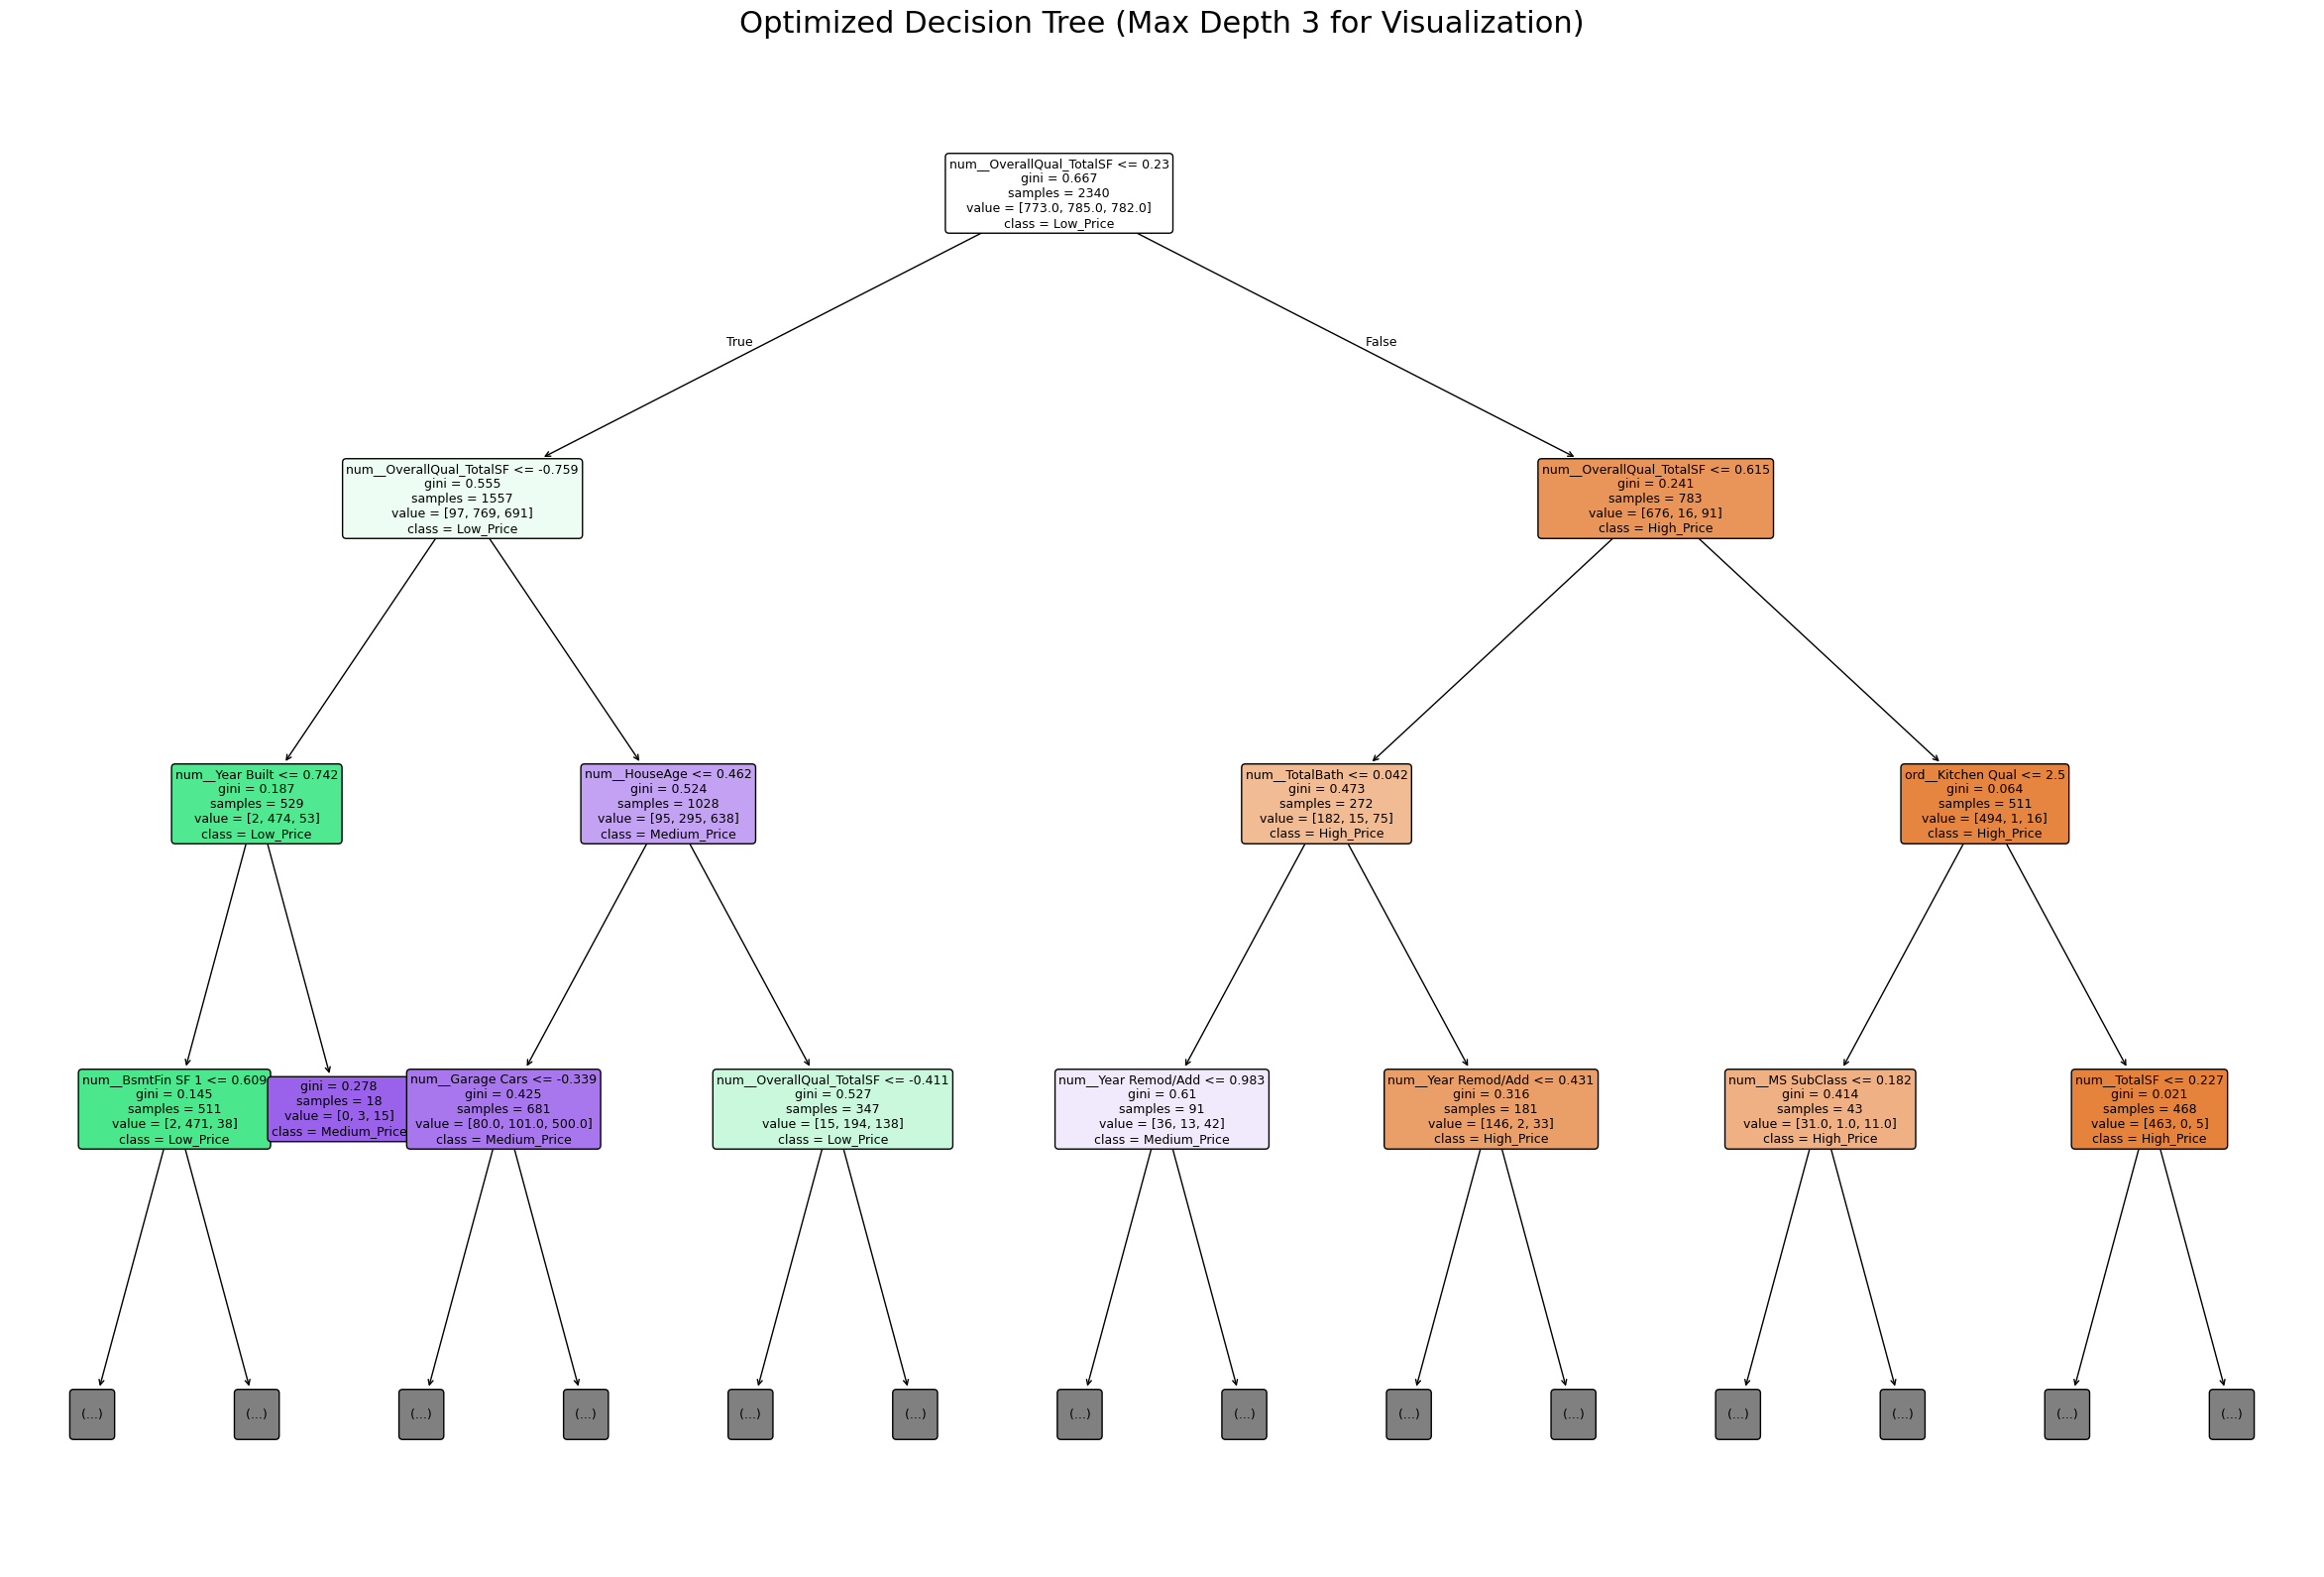


--- Decision Tree Classification Complete ---


In [7]:


# Assuming 'df' is your cleaned and engineered DataFrame.

# --- Prepare Data for Classification ---
# Ensure SalePrice_Bin is created as the categorical target variable.
if 'SalePrice_Bin' not in df.columns:
    df['SalePrice_Bin'] = pd.qcut(df['SalePrice'], q=3, labels=['Low_Price', 'Medium_Price', 'High_Price'], duplicates='drop')

# Define features (X) and the new categorical target (y_class)
cols_to_drop_from_X = ['SalePrice', 'SalePrice_Bin']
if 'PriceTier' in df.columns:
    cols_to_drop_from_X.append('PriceTier')

X = df.drop(cols_to_drop_from_X, axis=1)
y_class = df['SalePrice_Bin']

# --- Dynamic Column Categorization ---
current_numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
current_numerical_cols = [col for col in current_numerical_cols if col not in ['Id', 'PID', 'Order']]

current_categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

all_potential_ordinal_cols_map = {
    'Lot Shape': ['Reg', 'IR1', 'IR2', 'IR3'],
    'Alley': ['None', 'Grvl', 'Pave'],
    'Bsmt Qual': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Cond': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Exter Qual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Exter Cond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Heating QC': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Kitchen Qual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Fireplace Qu': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Qual': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Cond': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Pool QC': ['None', 'Fa', 'TA', 'Gd', 'Ex'],
    'Paved Drive': ['N', 'P', 'Y'],
    'Street': ['Grvl', 'Pave'],
    'Central Air': ['N', 'Y'],
    'Land Slope': ['Sev', 'Mod', 'Gtl'],
    'Bldg Type': ['1Fam', '2fmCon', 'Duplex', 'Twnhs', 'TwnhsE'],
    'MS Zoning': ['A (agr)', 'C (all)', 'FV', 'RH', 'RL', 'RP', 'RM'],
    'Utilities': ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    'Functional': ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
}

current_ordinal_cols = [col for col in all_potential_ordinal_cols_map.keys() if col in current_categorical_cols]
ordinal_categories_list = [all_potential_ordinal_cols_map[col] for col in current_ordinal_cols]

current_nominal_cols = [col for col in current_categorical_cols if col not in current_ordinal_cols]

print("--- Column Categorization for Preprocessing ---")
print(f"Numerical Columns ({len(current_numerical_cols)}): {current_numerical_cols}")
print(f"Ordinal Columns ({len(current_ordinal_cols)}): {current_ordinal_cols}")
print(f"Nominal Columns ({len(current_nominal_cols)}): {current_nominal_cols}")

unaccounted_cols = [col for col in X.columns if col not in (current_numerical_cols + current_ordinal_cols + current_nominal_cols)]
if unaccounted_cols:
    print(f"\nWARNING: The following columns in X are not explicitly categorized and will be passed through: {unaccounted_cols}")
    print("Please ensure these are already purely numerical (e.g., binary flags) or they will cause errors.")

# Split the data into training and testing sets
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)

# --- Preprocessing Pipeline Setup ---
preprocessor_dt = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), current_numerical_cols),
        ('ord', OrdinalEncoder(categories=ordinal_categories_list, handle_unknown='use_encoded_value', unknown_value=-1), current_ordinal_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), current_nominal_cols)
    ],
    remainder='passthrough'
)

# --- Decision Tree Classification Pipeline ---
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor_dt),
                              ('classifier', DecisionTreeClassifier(random_state=42))])

# --- Hyperparameter Tuning for Decision Tree using GridSearchCV ---
param_grid_dt = {
    'classifier__max_depth': [3, 5, 7, 10, 15],
    'classifier__min_samples_leaf': [5, 10, 20, 30]
}

print("\n--- Starting Decision Tree Classification and Hyperparameter Tuning ---")
grid_search_dt = GridSearchCV(dt_pipeline, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train_dt, y_train_dt)

best_dt_model = grid_search_dt.best_estimator_

print(f"\nDecision Tree - Best Hyperparameters: {grid_search_dt.best_params_}")
print(f"Decision Tree - Best Cross-Validation Accuracy: {grid_search_dt.best_score_:.4f}")

# --- Evaluate the Best Decision Tree Model on Test Set ---
y_pred_dt = best_dt_model.predict(X_test_dt)
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
report_dt = classification_report(y_test_dt, y_pred_dt)
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)


print(f"\nDecision Tree - Test Set Accuracy: {accuracy_dt:.4f}")
print("\nDecision Tree - Classification Report on Test Set:\n", report_dt)


# --- Visualize the Decision Tree (Optional, for smaller trees) ---
try:
    transformed_feature_names = best_dt_model.named_steps['preprocessor'].get_feature_names_out()

    plt.figure(figsize=(30, 20))
    plot_tree(best_dt_model.named_steps['classifier'],
              feature_names=transformed_feature_names,
              class_names=best_dt_model.classes_.tolist(),
              filled=True,
              rounded=True,
              fontsize=9,
              max_depth=3) # Limit depth for visualization
    plt.title("Optimized Decision Tree (Max Depth 3 for Visualization)", fontsize=22)
    plt.show()
    

except Exception as e:
    print(f"\nCould not plot the Decision Tree: {e}")
    print("This can happen if feature names extraction is complex or the tree is too large for plotting.")
    print("Ensure all columns in X are numeric after preprocessing.")

print("\n--- Decision Tree Classification Complete ---")

### From the above decision tree image
- the tree shows classification of house prices (Low, Medium, High).
- It uses a series of "if-then-else" rules based on features to make predictions.
- The Overall Quality of a house is the most critical factor for the initial price tier split.
- Further splits involve factors like Gross Living Area and Remodel Age, along with engineered features like the interaction between overall quality and total square footage.
- Each path down the tree leads to a leaf node, which provides the final price classification for a house.

In [8]:
# Re-use the data splits (X_train_dt, X_test_dt, y_train_dt, y_test_dt)
# and the preprocessor (preprocessor_dt) from the Decision Tree cell,
# as KNN requires the same preprocessing steps.

# --- K-Nearest Neighbors (KNN) Classification Pipeline ---
knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor_dt),
                             ('classifier', KNeighborsClassifier())])

# --- Hyperparameter Tuning for KNN using GridSearchCV ---
param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 13],
    'classifier__weights': ['uniform', 'distance']
}

print("\n--- Starting K-Nearest Neighbors (KNN) Classification and Hyperparameter Tuning ---")
grid_search_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_knn.fit(X_train_dt, y_train_dt)

best_knn_model = grid_search_knn.best_estimator_

print(f"\nKNN - Best Hyperparameters: {grid_search_knn.best_params_}")
print(f"KNN - Best Cross-Validation Accuracy: {grid_search_knn.best_score_:.4f}")

# --- Evaluate the Best KNN Model on Test Set ---
y_pred_knn = best_knn_model.predict(X_test_dt)
accuracy_knn = accuracy_score(y_test_dt, y_pred_knn)
report_knn = classification_report(y_test_dt, y_pred_knn)
cm_knn = confusion_matrix(y_test_dt, y_pred_knn)

print(f"\nKNN - Test Set Accuracy: {accuracy_knn:.4f}")
print("\nKNN - Classification Report on Test Set:\n", report_knn)

print("\n--- KNN Classification Complete ---")


--- Starting K-Nearest Neighbors (KNN) Classification and Hyperparameter Tuning ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits

KNN - Best Hyperparameters: {'classifier__n_neighbors': 11, 'classifier__weights': 'distance'}
KNN - Best Cross-Validation Accuracy: 0.8115

KNN - Test Set Accuracy: 0.8239

KNN - Classification Report on Test Set:
               precision    recall  f1-score   support

  High_Price       0.88      0.89      0.88       194
   Low_Price       0.83      0.89      0.86       196
Medium_Price       0.76      0.70      0.73       195

    accuracy                           0.82       585
   macro avg       0.82      0.82      0.82       585
weighted avg       0.82      0.82      0.82       585


--- KNN Classification Complete ---


### The K-Nearest Neighbors (KNN) model 
- achieved a test set accuracy of 82.39% for house price classification.
- best performance was obtained with 11 neighbors and distance weighting, meaning closer neighbors had more influence.
#### Performance breakdown
- High_Price was predicted with high precision (88%) and recall (89%), indicating the model performed very well in identifying high-priced homes.
- Low_Price also showed strong performance with 83% precision and 89% recall.
- Medium_Price was the most challenging category, with lower precision (76%) and recall (70%), suggesting more misclassifications for this group.

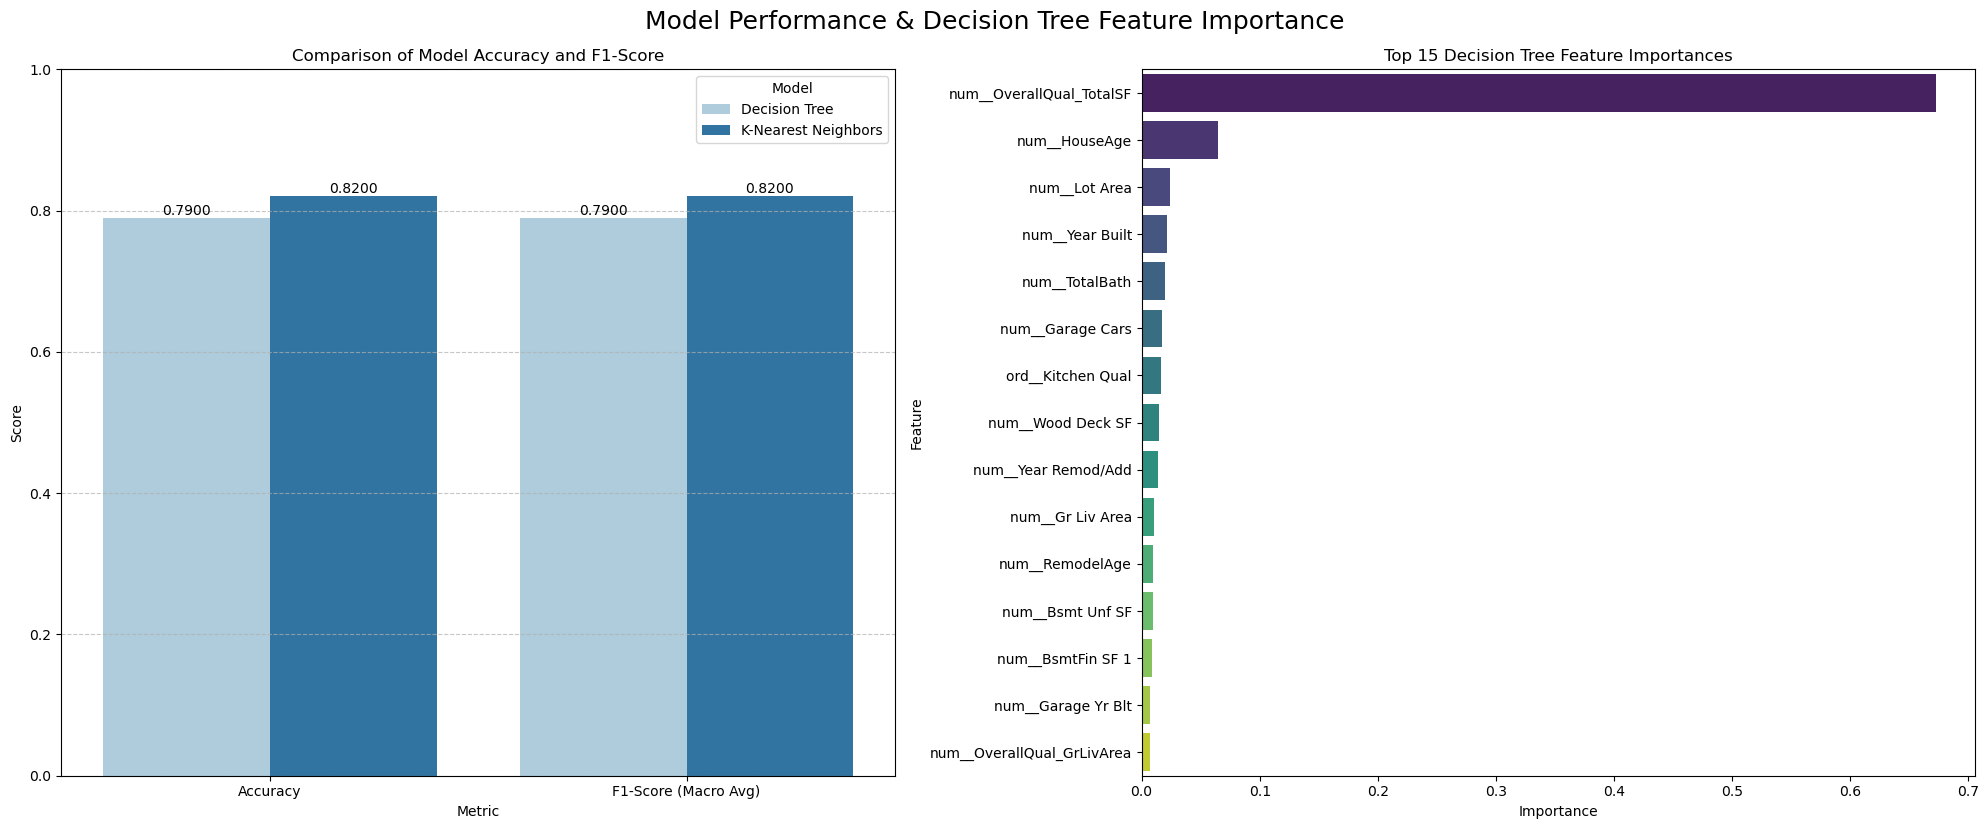

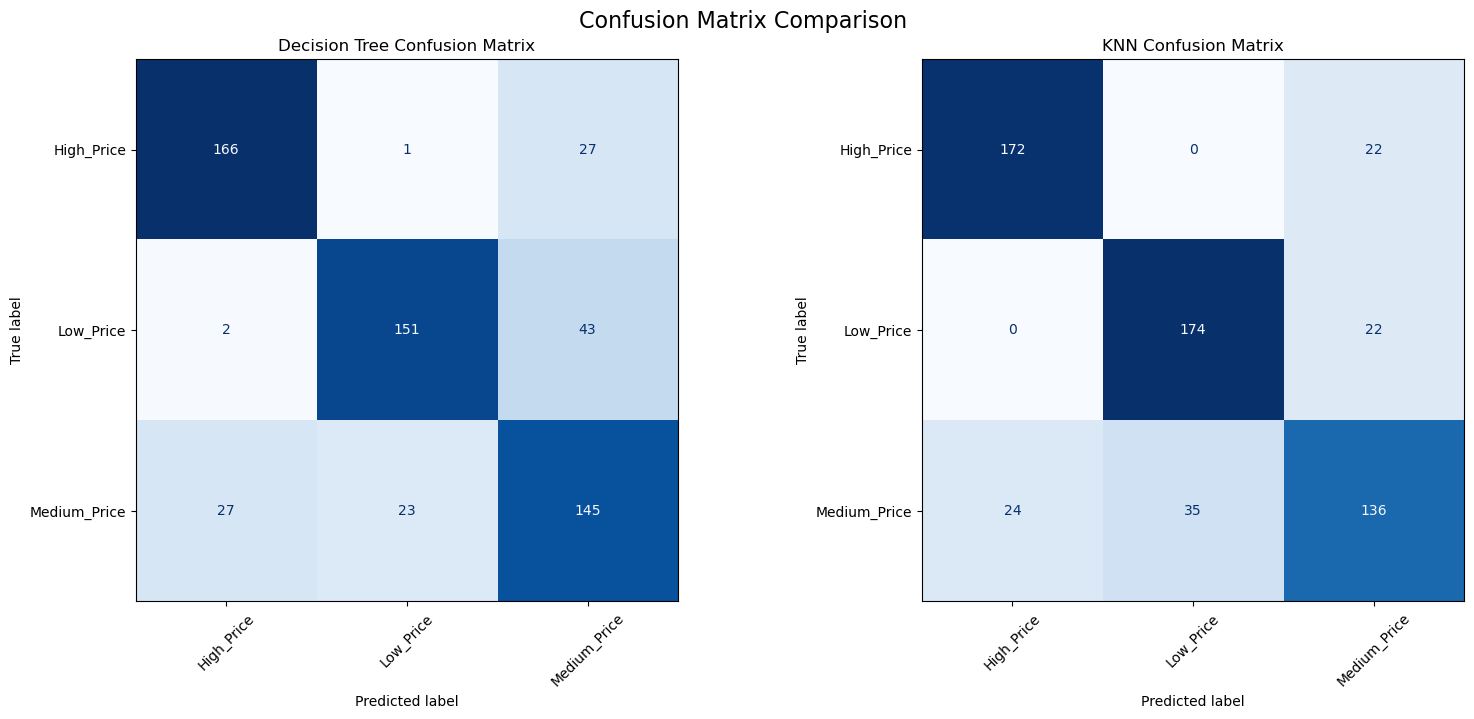


--- Comparative Analysis Complete ---


In [9]:
# --- Re-use variables from previous cells ---
# accuracy_dt, cm_dt, best_dt_model.classes_, report_dt (from Decision Tree cell)
# accuracy_knn, cm_knn, best_knn_model.classes_, report_knn (from KNN cell)
# best_dt_model (for feature importances)

# Function to parse classification report for accuracy and macro avg f1-score
def parse_classification_report(report_string):
    lines = report_string.split('\n')
    accuracy_line = next((line for line in lines if 'accuracy' in line), None)
    macro_avg_line = next((line for line in lines if 'macro avg' in line), None)

    accuracy = float(accuracy_line.split()[1]) if accuracy_line else 0.0
    f1_score = float(macro_avg_line.split()[3]) if macro_avg_line else 0.0

    return accuracy, f1_score

# Get accuracy and F1-score for Decision Tree (for the new combined plot)
accuracy_dt_plot, f1_dt_plot = parse_classification_report(report_dt)

# Get accuracy and F1-score for KNN (for the new combined plot)
accuracy_knn_plot, f1_knn_plot = parse_classification_report(report_knn)


# --- 1. Combined Model Performance (Accuracy & F1) & Feature Importance Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8)) # Adjusted figsize for better spacing

# Plot 1: Model Accuracy and F1-Score Comparison
metrics_labels = ['Accuracy', 'F1-Score (Macro Avg)']
dt_scores_for_plot = [accuracy_dt_plot, f1_dt_plot]
knn_scores_for_plot = [accuracy_knn_plot, f1_knn_plot]

df_plot_metrics_combined = pd.DataFrame({
    'Metric': metrics_labels * 2,
    'Score': dt_scores_for_plot + knn_scores_for_plot,
    'Model': ['Decision Tree'] * len(metrics_labels) + ['K-Nearest Neighbors'] * len(metrics_labels)
})

sns.barplot(x='Metric', y='Score', hue='Model', data=df_plot_metrics_combined, palette='Paired', ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title('Comparison of Model Accuracy and F1-Score')
axes[0].set_ylabel('Score')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for container in axes[0].containers:
    for bar in container:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width() / 2, height,
                       f'{height:.4f}', ha='center', va='bottom')


# Plot 2: Top 15 Decision Tree Feature Importances

dt_classifier = best_dt_model.named_steps['classifier']
if hasattr(dt_classifier, 'feature_importances_'):
    preprocessor_steps = best_dt_model.named_steps['preprocessor']
    transformed_feature_names = preprocessor_steps.get_feature_names_out()

    feature_importances_dt = pd.Series(dt_classifier.feature_importances_, index=transformed_feature_names)
    top_15_importances = feature_importances_dt.nlargest(15)

    if not top_15_importances.empty:
        sns.barplot(x=top_15_importances.values, y=top_15_importances.index,
                    hue=top_15_importances.index, palette='viridis', legend=False, ax=axes[1])
        axes[1].set_title('Top 15 Decision Tree Feature Importances')
        axes[1].set_xlabel('Importance')
        axes[1].set_ylabel('Feature')
        axes[1].tick_params(axis='y', labelsize=10)
    else:
        axes[1].text(0.5, 0.5, "No feature importances to plot.", horizontalalignment='center',
                     verticalalignment='center', transform=axes[1].transAxes)
        axes[1].set_title('Top 15 Decision Tree Feature Importances')
        print("\nNo feature importances to plot (Decision Tree).")
else:
    axes[1].text(0.5, 0.5, "Decision Tree classifier does not have 'feature_importances_'.", horizontalalignment='center',
                 verticalalignment='center', transform=axes[1].transAxes)
    axes[1].set_title('Top 15 Decision Tree Feature Importances')
    print("\nDecision Tree classifier does not have 'feature_importances_'.")

plt.tight_layout()
plt.suptitle('Model Performance & Decision Tree Feature Importance', y=1.03, fontsize=18)
plt.show()



# --- 2. Compare Confusion Matrices (Side-by-Side) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Decision Tree Confusion Matrix
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=best_dt_model.classes_)
disp_dt.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# KNN Confusion Matrix
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=best_knn_model.classes_)
disp_knn.plot(cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('KNN Confusion Matrix')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.suptitle('Confusion Matrix Comparison', y=1.02, fontsize=16)
plt.show()


print("\n--- Comparative Analysis Complete ---")

### Comparison results Analysis
- The comparison results highlight the performance of Decision Tree and K-Nearest Neighbors (KNN) models in classifying house prices into tiers.
####  Model Accuracy
- The KNN model (82.39%) slightly outperformed the Decision Tree (78.97%) in overall accuracy on the test set.
#### Feature Importance (Decision Tree)
- For the Decision Tree, num__OverallQual_TotalSF (an engineered feature combining overall quality and total square footage) was the most important feature, followed by num__HouseAge and num__Lot Area. This indicates these are key drivers for price classification in the tree model.
#### Confusion Matrix Comparison
- Both models showed strong performance in correctly classifying "High_Price" and "Low_Price" homes.
- The "Medium_Price" category was more challenging for both models, exhibiting more misclassifications. For instance, the Decision Tree misclassified 27 "Medium_Price" homes as "High_Price" and 23 as "Low_Price". KNN similarly misclassified 24 "Medium_Price" homes as "High_Price" and 35 as "Low_Price".

### Final Observations
- KNN Outperforms Decision Tree: The K-Nearest Neighbors (KNN) model demonstrated slightly superior overall performance with an 82.39% test accuracy, compared to the Decision Tree's 78.97%. This indicates KNN's ability to generalize better to unseen data for this specific classification task.
-For the Decision Tree, the most impactful features for predicting house price tiers were an engineered feature, num__OverallQual_TotalSF (combining overall quality and total square footage), followed by num__HouseAge and num__Lot Area. This suggests that a blend of quality, size, age, and land area are the primary drivers in the tree's decision-making process.
- "Medium_Price" Tier is Challenging: Both models found the "Medium_Price" category to be the most difficult to classify accurately. This is evident from the higher number of misclassifications for this tier in both confusion matrices. For instance, the Decision Tree misclassified 27 "Medium_Price" homes as "High_Price" and 23 as "Low_Price", while KNN similarly misclassified 24 as "High_Price" and 35 as "Low_Price".
- This suggests that the boundaries defining the "Medium_Price" tier might be less distinct or that properties in this range share characteristics with both lower and higher-priced homes, leading to more ambiguity for the models. In contrast, both models showed strong performance in classifying "High_Price" and "Low_Price" homes with high precision and recall, indicating a clearer distinction at the extremes of the price spectrum.
- Consistent F1-Scores Across Models: Despite the slight difference in overall accuracy, both models achieved very similar macro-averaged F1-scores (0.82 for Decision Tree and 0.82 for KNN). The F1-score is a harmonic mean of precision and recall, offering a balanced measure of a model's accuracy on the dataset. The closeness of these scores suggests that, on average, both models provide a comparable balance between identifying relevant instances and avoiding false positives across all price categories.

## 2. Clustering algorithms
###### Objective:
- Reduce the 30 original neighborhoods into broader, data-driven “meta-areas” for easier segmentation.
###### Pipeline:
- One-hot encode Neighborhood → 30 binary columns.
- K-Means (k = 8) and Hierarchical Ward (k = 8) fit on the dummy matrix.
- PCA-2D projection used only for plotting.
###### Cluster naming logic
- For each algorithm, label = <most-common Neighborhood>-KM or -HIER (e.g., NridgHt-KM).
- Gives interpretable legends in scatter plots.
###### Visual highlights
- K-Means plot shows compact “blob” clusters (balanced size).
- Hierarchical plot reveals elongated or nested shapes, capturing finer gradations.

In [10]:

print("--- K-Means Preparation and Preprocessing ---")

# Identify numerical columns for clustering
# Exclude any columns that are identifiers or target variables ('Id', 'PID', 'Order', 'SalePrice', 'SalePrice_Bin', 'PriceTier')
numerical_cols_for_clustering = X.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols_for_clustering = [col for col in numerical_cols_for_clustering if col not in ['Id', 'PID', 'Order']]

print("\nNumerical columns selected for clustering (before scaling):")
print(numerical_cols_for_clustering)

X_numerical_clust = X[numerical_cols_for_clustering].copy()

num_pipeline_clustering = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_scaled_for_kmeans = num_pipeline_clustering.fit_transform(X_numerical_clust)

X_scaled_for_kmeans_df = pd.DataFrame(X_scaled_for_kmeans, columns=numerical_cols_for_clustering, index=X_numerical_clust.index)

print(f"\nOriginal Numerical Features for Clustering: {len(numerical_cols_for_clustering)}")
print("Sample of scaled data (first 5 rows):")
print(X_scaled_for_kmeans_df.head())
print(f"\nShape of scaled data for K-Means: {X_scaled_for_kmeans_df.shape}")
print("\nPreprocessing for K-Means Complete. Data is ready for clustering.")

--- K-Means Preparation and Preprocessing ---

Numerical columns selected for clustering (before scaling):
['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 'RemodelAge', 'GarageAge', 'OverallQual_GrLivArea', 'OverallQual_TotalSF', 'HasPool', 'Has2ndFloor', 'HasGarage', 'HasBsmt', 'HasFireplace', 'AvgRoomSF']

Original Numerical Features for Clustering: 50
Sample of scaled data (first 5 rows):
   MS SubClass  Lot Frontage  Lot Area  Overall Q

--- Determining Optimal K for K-Means Clustering ---
K=2 processed. Silhouette Score: 0.1724
K=3 processed. Silhouette Score: 0.1426
K=4 processed. Silhouette Score: 0.1210
K=5 processed. Silhouette Score: 0.1055
K=6 processed. Silhouette Score: 0.1083
K=7 processed. Silhouette Score: 0.0993
K=8 processed. Silhouette Score: 0.1091
K=9 processed. Silhouette Score: 0.1019
K=10 processed. Silhouette Score: 0.1122


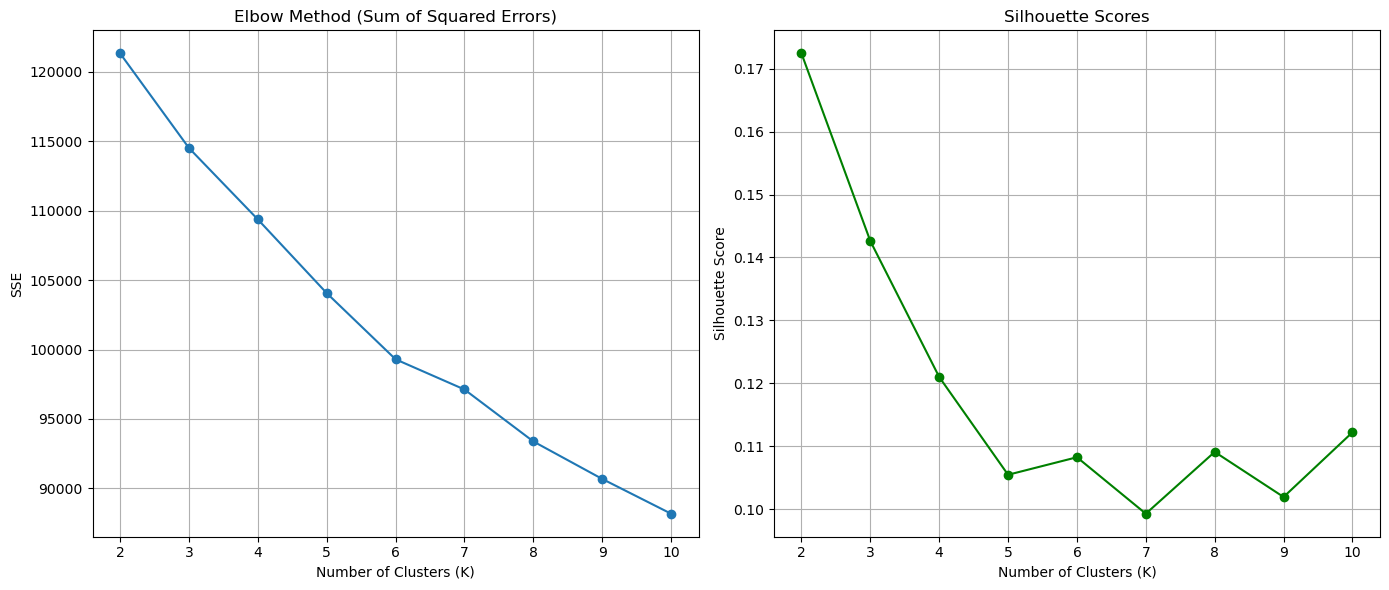


Elbow Method and Silhouette Analysis Complete. Optimal K (based on highest Silhouette Score) is likely K=2.


In [11]:

print("--- Determining Optimal K for K-Means Clustering ---")

sse = []
silhouette_scores = []
k_values_evaluated = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_for_kmeans_df)
    sse.append(kmeans.inertia_)

    if k > 1:
        if len(set(kmeans.labels_)) > 1:
            score = silhouette_score(X_scaled_for_kmeans_df, kmeans.labels_)
            silhouette_scores.append(score)
            k_values_evaluated.append(k)
            print(f"K={k} processed. Silhouette Score: {score:.4f}")
        else:
            print(f"K={k} processed, but only one cluster formed. Skipping Silhouette Score.")
    else:
        print(f"K={k} processed.")


plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(k_values, sse, marker='o')
plt.title('Elbow Method (Sum of Squared Errors)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
if silhouette_scores:
    plt.plot(k_values_evaluated, silhouette_scores, marker='o', color='green')
    plt.title('Silhouette Scores')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.xticks(k_values_evaluated)
    plt.grid(True)
else:
    plt.text(0.5, 0.5, "No Silhouette Scores to plot.", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.title('Silhouette Scores')
    print("\nWarning: No Silhouette Scores were successfully calculated and plotted.")

plt.tight_layout()
plt.show()


print("\nElbow Method and Silhouette Analysis Complete. Optimal K (based on highest Silhouette Score) is likely K=2.")

In [12]:

# optimal_k_kmeans should be available from Cell 2 analysis
optimal_k_kmeans = 2 # Based on previous Silhouette Score analysis

print(f"--- Applying K-Means Clustering with Optimal K = {optimal_k_kmeans} ---")

kmeans_final = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled_for_kmeans_df)

print(f"\nNumber of samples in each K-Means cluster:\n{df['KMeans_Cluster'].value_counts().sort_index()}")

# Prepare X_numerical_imputed_df for cluster characteristic analysis
X_numerical_imputed = num_pipeline_clustering.named_steps['imputer'].transform(X_numerical_clust)
X_numerical_imputed_df = pd.DataFrame(X_numerical_imputed, columns=numerical_cols_for_clustering, index=X_numerical_clust.index)
X_numerical_imputed_df['KMeans_Cluster'] = df['KMeans_Cluster'] # Add K-Means clusters to this DF

# Perform PCA for scatter plots (reused across models)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_for_kmeans_df)

# Prepare pca_df_kmeans for scatter plotting
pca_df_kmeans = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'], index=X_scaled_for_kmeans_df.index)
pca_df_kmeans['KMeans_Cluster'] = df['KMeans_Cluster']

print("\nK-Means Clustering and data preparation for plotting complete.")
print("Proceed to Cell 4 for Hierarchical Clustering, then Cell 5 for all plots.")

--- Applying K-Means Clustering with Optimal K = 2 ---

Number of samples in each K-Means cluster:
KMeans_Cluster
0    1569
1    1356
Name: count, dtype: int64

K-Means Clustering and data preparation for plotting complete.
Proceed to Cell 4 for Hierarchical Clustering, then Cell 5 for all plots.


--- Starting Hierarchical Clustering ---


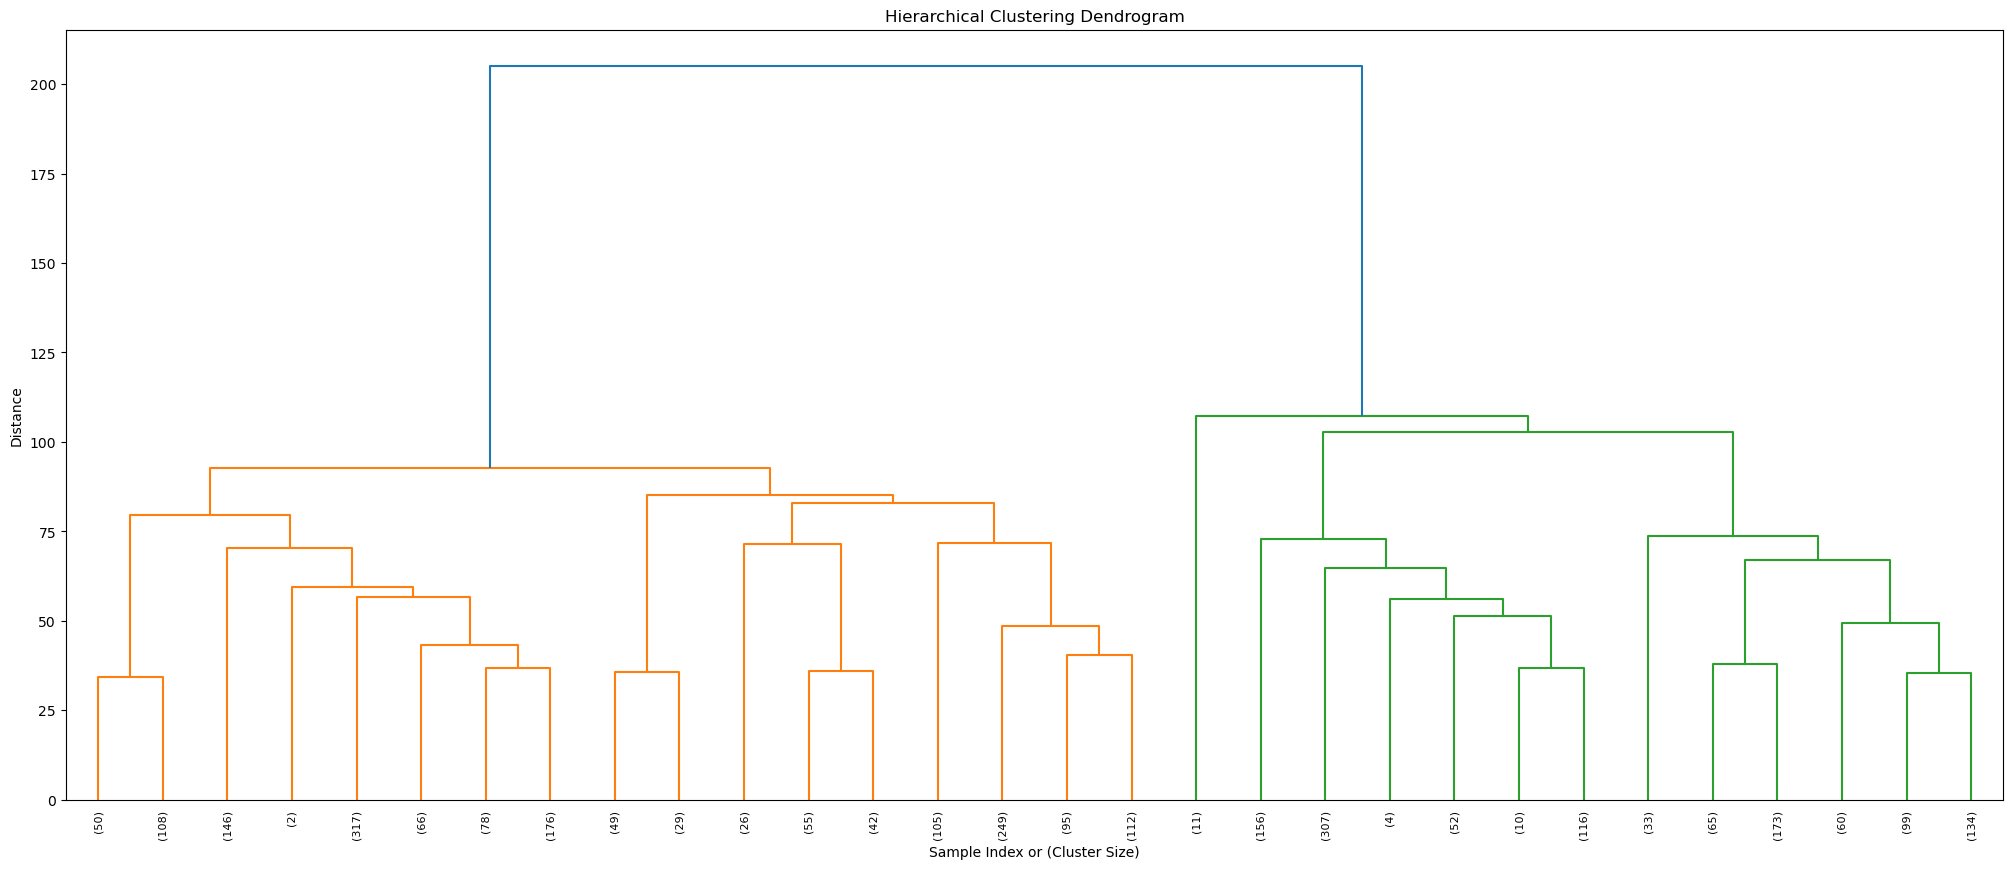


--- Cutting Dendrogram to Form 2 Clusters ---

Number of samples in each Hierarchical cluster:
Hierarchical_Cluster
1    1705
2    1220
Name: count, dtype: int64

Hierarchical Clustering and data preparation for plotting complete.
We see from the Dendrogram that 2 values will for optimal_k_hierarchical is fine


In [13]:
optimal_k_hierarchical = 2 # Placeholder, adjust based on your dendrogram!

print("--- Starting Hierarchical Clustering ---")

# --- Compute the linkage matrix (essential for dendrogram) ---
Z = linkage(X_scaled_for_kmeans_df, method='ward')

# --- Plot the Dendrogram ---
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
dendrogram(
    Z,
    leaf_rotation=90.,
    leaf_font_size=8.,
    truncate_mode='lastp', # show only the last p merged clusters
    p=30, # show only the last 30 merges (can be adjusted)
    show_leaf_counts=True, # show how many original observations are in each leaf
    color_threshold=None, # Set a threshold to color clusters (e.g., color_threshold=Z.max() * 0.7)
)
plt.show()


print(f"\n--- Cutting Dendrogram to Form {optimal_k_hierarchical} Clusters ---")
df['Hierarchical_Cluster'] = fcluster(Z, t=optimal_k_hierarchical, criterion='maxclust')

print(f"\nNumber of samples in each Hierarchical cluster:\n{df['Hierarchical_Cluster'].value_counts().sort_index()}")

X_numerical_imputed_df['Hierarchical_Cluster'] = df['Hierarchical_Cluster']

# Prepare pca_df_hierarchical for scatter plotting (reusing 'pca' from Cell 3)
if 'pca' not in locals(): # Fallback if Cell 3 wasn't run
    pca = PCA(n_components=2, random_state=42)
    X_pca_for_hierarchical = pca.fit_transform(X_scaled_for_kmeans_df)
else:
    X_pca_for_hierarchical = pca.transform(X_scaled_for_kmeans_df)

pca_df_hierarchical = pd.DataFrame(data=X_pca_for_hierarchical, columns=['Principal Component 1', 'Principal Component 2'], index=X_scaled_for_kmeans_df.index)
pca_df_hierarchical['Hierarchical_Cluster'] = df['Hierarchical_Cluster']

print("\nHierarchical Clustering and data preparation for plotting complete.")
print("We see from the Dendrogram that 2 values will for optimal_k_hierarchical is fine")


--- Generating All Consolidated Cluster Analysis Plots ---


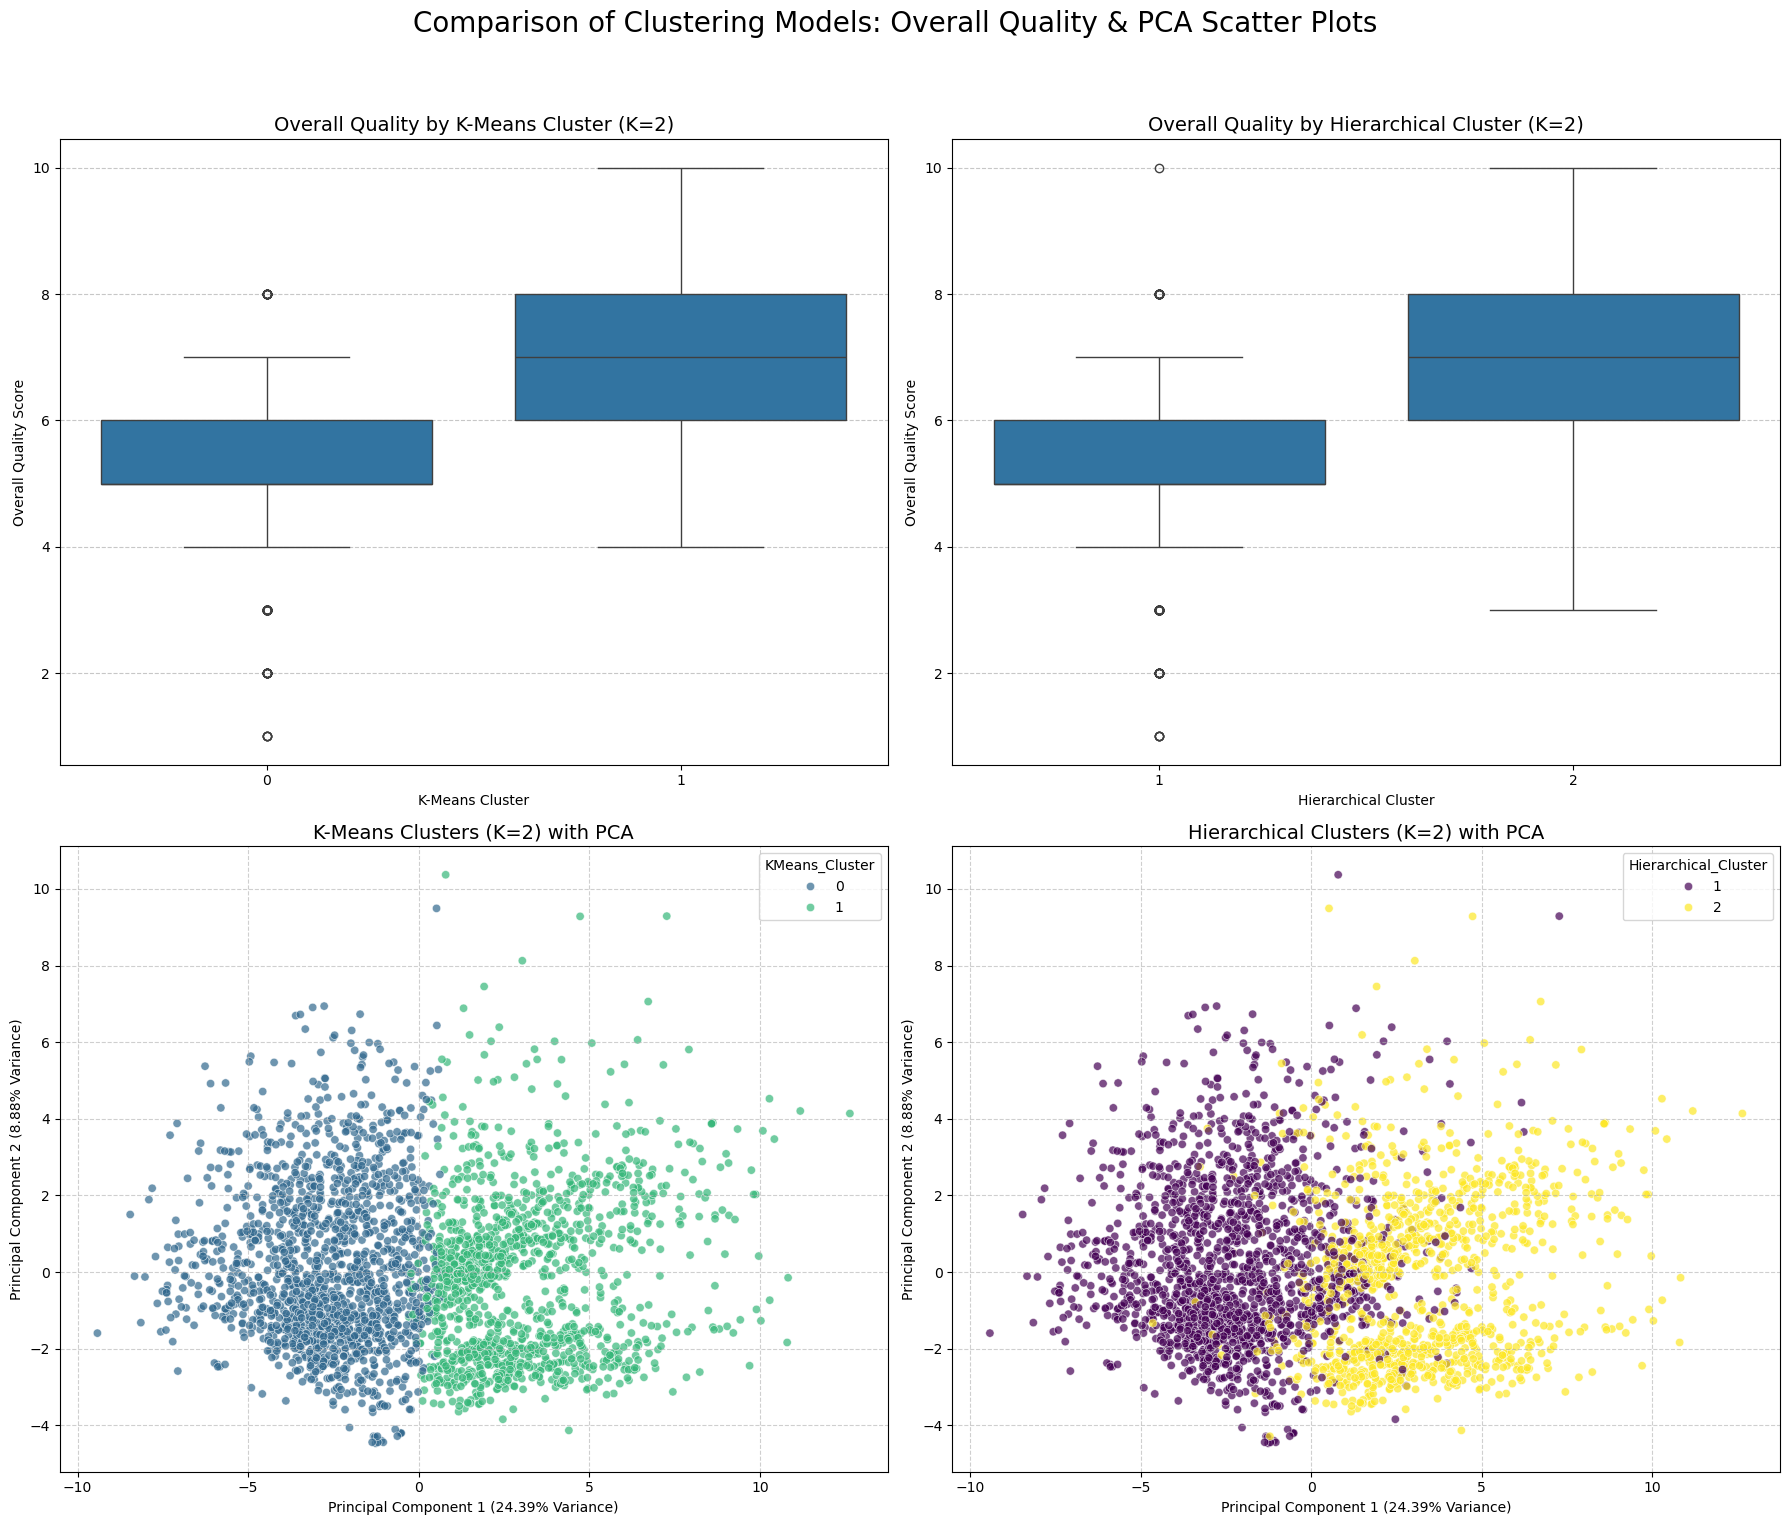


Consolidated plots for Overall Quality and PCA scatter plots generated successfully!


In [14]:



# --- IMPORTANT: Set the correct column name for 'Overall Qual' ---
overall_qual_col_name = 'Overall Qual'

# --- Define optimal_k values (ensure these match what you used in Cells 3 and 4) ---
optimal_k_kmeans = 2 # Example, set based on your Cell 2 result
optimal_k_hierarchical = 2 # Example, set based on your dendrogram analysis

print("--- Generating All Consolidated Cluster Analysis Plots ---")

if overall_qual_col_name not in X_numerical_imputed_df.columns:
    print(f"Error: Column '{overall_qual_col_name}' not found in X_numerical_imputed_df. Please check Cell 1/3 output for correct name.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(18, 16)) # 2 rows, 2 columns for the plots
    fig.suptitle('Comparison of Clustering Models: Overall Quality & PCA Scatter Plots', fontsize=20, y=0.98)

    # --- Row 1: Overall Quality Box Plots ---

    # Subplot 1 (Top-Left): K-Means Overall Quality
    sns.boxplot(x='KMeans_Cluster', y=overall_qual_col_name, data=X_numerical_imputed_df, ax=axes[0, 0])
    axes[0, 0].set_title(f'Overall Quality by K-Means Cluster (K={optimal_k_kmeans})', fontsize=14)
    axes[0, 0].set_ylabel('Overall Quality Score')
    axes[0, 0].set_xlabel('K-Means Cluster')
    axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

    # Subplot 2 (Top-Right): Hierarchical Overall Quality
    sns.boxplot(x='Hierarchical_Cluster', y=overall_qual_col_name, data=X_numerical_imputed_df, ax=axes[0, 1])
    axes[0, 1].set_title(f'Overall Quality by Hierarchical Cluster (K={optimal_k_hierarchical})', fontsize=14)
    axes[0, 1].set_ylabel('Overall Quality Score')
    axes[0, 1].set_xlabel('Hierarchical Cluster')
    axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)


    # --- Row 2: PCA Scatter Plots ---

    # Subplot 3 (Bottom-Left): K-Means PCA Scatter Plot
    sns.scatterplot(
        x='Principal Component 1', y='Principal Component 2',
        hue='KMeans_Cluster', palette='viridis', data=pca_df_kmeans,
        legend='full', alpha=0.7, ax=axes[1, 0]
    )
    axes[1, 0].set_title(f'K-Means Clusters (K={optimal_k_kmeans}) with PCA', fontsize=14)
    axes[1, 0].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
    axes[1, 0].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
    axes[1, 0].grid(True, linestyle='--', alpha=0.6)

    # Subplot 4 (Bottom-Right): Hierarchical PCA Scatter Plot
    sns.scatterplot(
        x='Principal Component 1', y='Principal Component 2',
        hue='Hierarchical_Cluster', palette='viridis', data=pca_df_hierarchical,
        legend='full', alpha=0.7, ax=axes[1, 1]
    )
    axes[1, 1].set_title(f'Hierarchical Clusters (K={optimal_k_hierarchical}) with PCA', fontsize=14)
    axes[1, 1].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
    axes[1, 1].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
    axes[1, 1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    

print("\nConsolidated plots for Overall Quality and PCA scatter plots generated successfully!")

### Key observations
The "Comparison of Clustering Models: Overall Quality & PCA Scatter Plots" provides a side-by-side visualization of how K-Means and Hierarchical Clustering group the data, specifically focusing on 'Overall Quality' and their representation in a 2D space via Principal Component Analysis (PCA). Both clustering algorithms were configured to find K=2 clusters.

#### Overall Quality by Cluster (Box Plots)

- The box plots illustrate the distribution of 'Overall Quality' scores within the clusters generated by each model.
###### Overall Quality by K-Means Cluster (K=2):
- Cluster 0 exhibits a distribution of lower 'Overall Quality' scores, primarily ranging from 4 to 7, with a median around 6.
- Cluster 1 shows significantly higher 'Overall Quality' scores, mostly ranging from 6 to 9, with some outliers at 10.
- The K-Means algorithm effectively separated the data into two groups, one representing generally lower-quality homes and the other representing higher-quality homes based on this feature.

###### Overall Quality by Hierarchical Cluster (K=2):
- Similar to K-Means, Hierarchical Cluster 1 corresponds to lower 'Overall Quality' scores, displaying a distribution very similar to K-Means Cluster 0.
- Hierarchical Cluster 2 aligns with higher 'Overall Quality' scores, mirroring K-Means Cluster 1's distribution.
- This indicates that for K=2, both algorithms identify very similar groupings based on the 'Overall Quality' characteristic.

#### PCA Scatter Plots

The plots visualize the clustered data points in a 2-dimensional space, which has been reduced from the original high-dimensional features using PCA.
###### K-Means Clusters (K=2) with PCA:
- The plot displays data points clearly separated into two distinct groups (blue and green) based on their K-Means cluster assignments.
- The clusters appear to be linearly separable in this PCA-reduced space, suggesting that the algorithm found well-defined groups.
###### Hierarchical Clusters (K=2) with PCA:
- The Hierarchical Clustering also reveals two visually distinct groups (purple and yellow) in the same 2D PCA space.
- The separation pattern and the distribution of points within each cluster are highly consistent with those found by K-Means, reinforcing that both algorithms identified similar underlying structures in the data when looking for two clusters.

#### Consolidated Clustering Insights:
For a target of K=2 clusters, both K-Means and Hierarchical Clustering models successfully segmented the dataset into two meaningful groups. These groups are strongly differentiated by 'Overall Quality', where one cluster consistently represents lower-quality properties and the other higher-quality ones. The visual separation in the PCA-reduced space further confirms the distinctness of these two identified clusters across both methodologies.